# K-Means and Hierarchical Clustering

This notebook demonstrates **K-Means** and **Agglomerative (hierarchical)** clustering on a benchmark dataset (Iris). It includes preprocessing, cluster fitting, evaluation (silhouette score), and visualizations (PCA scatter + dendrogram).

In [1]:

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


## 1) Load benchmark dataset (Iris)

In [2]:

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2) Preprocessing: Standardize features

In [3]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=feature_names).head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 3) PCA projection to 2D for visualization

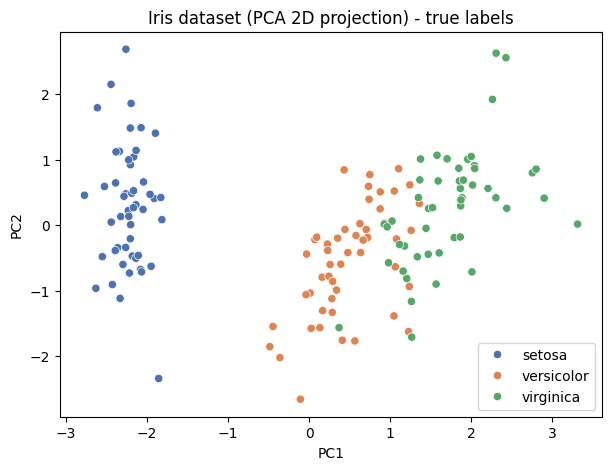

In [4]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=iris.target_names[y], palette='deep')
plt.title('Iris dataset (PCA 2D projection) - true labels')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


## 4) K-Means Clustering
- Use elbow method to select k
- Compute silhouette score
- Visualize clusters on PCA

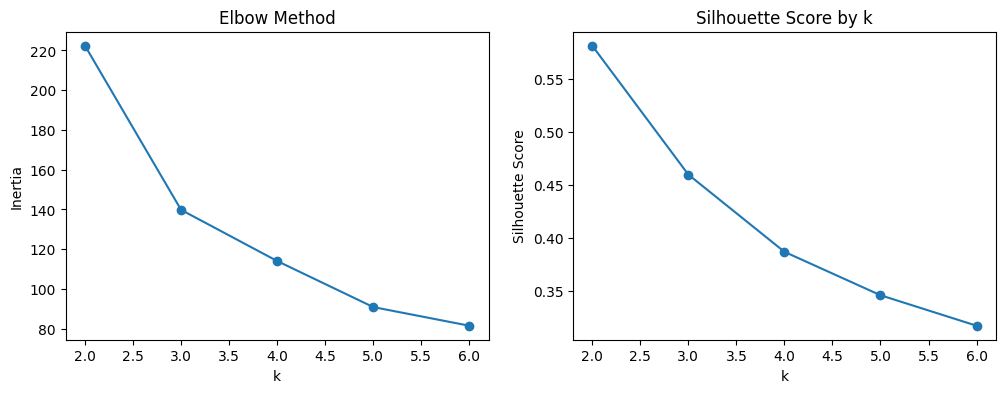

In [5]:

# Elbow method (inertia) & silhouette for k=2..6
inertias = []
sil_scores = []
K = range(2,7)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertias, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K, sil_scores, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette Score'); plt.title('Silhouette Score by k')
plt.show()


In [6]:

# Choose k=3 (known for Iris)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
klabels = kmeans.fit_predict(X_scaled)
print('Silhouette score (k=3):', round(silhouette_score(X_scaled, klabels),3))


Silhouette score (k=3): 0.46


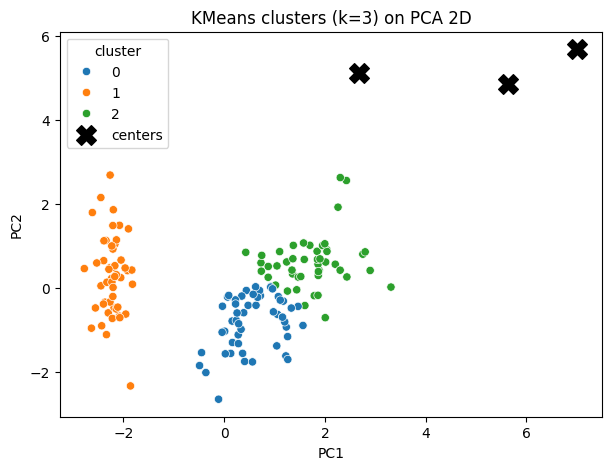

In [7]:

# Visualize KMeans clusters on PCA space
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=klabels, palette='tab10', legend='full')
centers = pca.transform(scaler.inverse_transform(kmeans.cluster_centers_))  # project cluster centers to PCA space
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='centers')
plt.title(f'KMeans clusters (k={k}) on PCA 2D'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()


## 5) Agglomerative (Hierarchical) Clustering
- Compute linkage and plot dendrogram
- Cut tree for n clusters and visualize

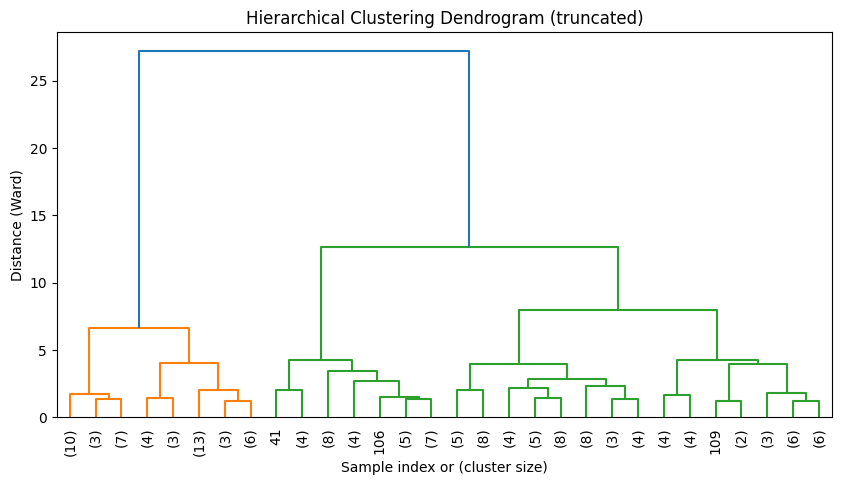

In [8]:

# Linkage (Ward) on scaled data for dendrogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance (Ward)')
plt.show()


In [11]:

# Fit AgglomerativeClustering with n_clusters=3
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
alabels = agg.fit_predict(X_scaled)
print('Silhouette score (agglomerative, n=3):', round(silhouette_score(X_scaled, alabels),3))


Silhouette score (agglomerative, n=3): 0.447


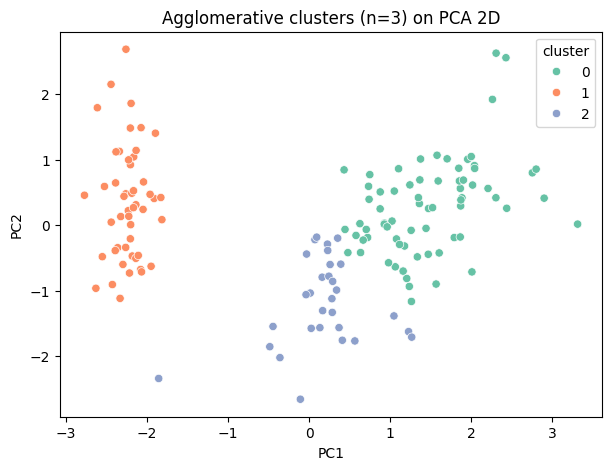

In [12]:

# Visualize Agglomerative clusters on PCA space
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=alabels, palette='Set2', legend='full')
plt.title('Agglomerative clusters (n=3) on PCA 2D'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()


## 6) Comparison and Conclusion
- Compare silhouette scores and visual separation.
- Tips:
  - Standardize features before clustering.
  - Use PCA for visualization but not for clustering unless needed.
  - Try different linkage methods (single, complete, average, ward) and distance metrics.

**End of Notebook**